# SMS Spam EDA, Logistic Regression, and KNN

This notebook performs exploratory data analysis and builds two supervised text classifiers:

- Logistic Regression with TF-IDF features
- K-Nearest Neighbors with TF-IDF features

Dataset path: `/home/durgaumadev/Documents/MTech/Security for Data Science/sms+spam+collection/SMSSpamCollection`

## 1. Imports and Settings

In [1]:
import os
from collections import Counter
from pathlib import Path
import re
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp")
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_colwidth", 160)

## 1.1 Helper Functions

In [2]:
def basic_text_eda(data, label_col="label", text_col="text"):
    """Create reusable text statistics for EDA."""
    eda_df = data.copy()
    eda_df[text_col] = eda_df[text_col].fillna("").astype(str)
    eda_df["char_count"] = eda_df[text_col].str.len()
    eda_df["word_count"] = eda_df[text_col].str.split().str.len()
    eda_df["unique_word_count"] = eda_df[text_col].str.lower().str.findall(r"[a-zA-Z]{2,}").map(lambda words: len(set(words)))
    eda_df["avg_word_length"] = eda_df[text_col].str.findall(r"[a-zA-Z]+").map(
        lambda words: np.mean([len(word) for word in words]) if words else 0
    )
    return eda_df


def show_label_distribution(data, label_col="label"):
    label_counts = data[label_col].value_counts().rename_axis(label_col).reset_index(name="count")
    label_counts["percentage"] = (label_counts["count"] / len(data) * 100).round(2)
    display(label_counts)

    plt.figure(figsize=(7, 4))
    ax = sns.countplot(data=data, x=label_col, order=label_counts[label_col])
    ax.set_title("Class Distribution")
    ax.set_xlabel("")
    ax.set_ylabel("Number of records")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


def plot_text_lengths(eda_df, label_col="label"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    clipped_chars = eda_df["char_count"].clip(upper=eda_df["char_count"].quantile(0.95))
    sns.histplot(
        data=eda_df.assign(char_count_clipped=clipped_chars),
        x="char_count_clipped",
        hue=label_col,
        bins=40,
        element="step",
        stat="density",
        common_norm=False,
        ax=axes[0],
    )
    axes[0].set_title("Character Count Distribution (95th percentile clipped)")
    axes[0].set_xlabel("Characters")

    clipped_words = eda_df["word_count"].clip(upper=eda_df["word_count"].quantile(0.95))
    sns.boxplot(data=eda_df.assign(word_count_clipped=clipped_words), x=label_col, y="word_count_clipped", ax=axes[1])
    axes[1].set_title("Word Count by Class (95th percentile clipped)")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Words")
    axes[1].tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()


def top_words_by_label(data, label_value, text_col="text", label_col="label", n=20):
    text = " ".join(data.loc[data[label_col] == label_value, text_col].dropna().astype(str).str.lower())
    words = re.findall(r"[a-zA-Z]{3,}", text)
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    return pd.DataFrame(Counter(words).most_common(n), columns=["word", "count"])


def evaluate_model(name, model, X_train, X_test, y_train, y_test, positive_label):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0,
    )
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "weighted_precision": precision,
        "weighted_recall": recall,
        "weighted_f1": f1,
    }

    print(f"{name} classification report")
    report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True, zero_division=0)).T
    display(report)

    labels = sorted(y_test.unique())
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format="d", xticks_rotation=30)
    plt.title(f"{name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

    if len(labels) == 2 and hasattr(model, "predict_proba"):
        try:
            positive_index = list(model.classes_).index(positive_label)
            y_score = model.predict_proba(X_test)[:, positive_index]
            y_test_binary = (y_test == positive_label).astype(int)
            metrics["roc_auc"] = roc_auc_score(y_test_binary, y_score)
            RocCurveDisplay.from_predictions(y_test_binary, y_score, name=name)
            plt.title(f"{name} ROC Curve")
            plt.tight_layout()
            plt.show()
        except ValueError:
            metrics["roc_auc"] = np.nan
    else:
        metrics["roc_auc"] = np.nan

    return metrics, model

## 2. Load Dataset

In [3]:
DATA_PATH = Path(r"/home/durgaumadev/Documents/MTech/Security for Data Science/sms+spam+collection/SMSSpamCollection")
df = pd.read_csv(DATA_PATH, sep="\t", names=["label", "text"], header=None)

df["text"] = df["text"].fillna("").astype(str)
df["label"] = df["label"].astype(str)

## 3. Basic Structure

In [4]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
display(df.head())

print("\nData types and missing values")
display(pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
}))

Shape: (5572, 2)

Columns: ['label', 'text']


,label,text
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"



Data types and missing values


,dtype,missing,missing_pct
label,str,0,0.0
text,str,0,0.0


## 4. Class Balance

,label,count,percentage
0,ham,4825,86.59
1,spam,747,13.41


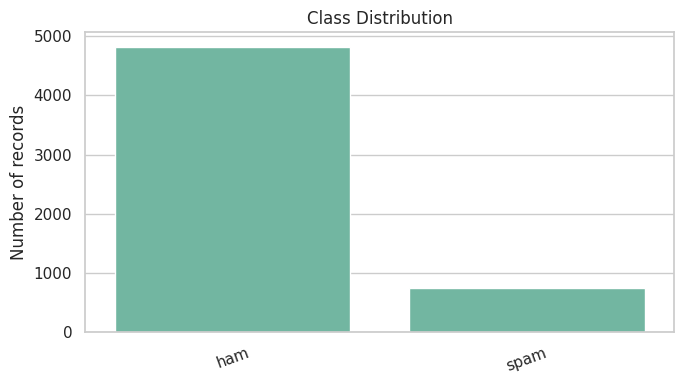

In [5]:
show_label_distribution(df, label_col="label")

## 5. Missing Values, Blank Text, and Duplicates

In [6]:
quality_summary = pd.DataFrame({
    "metric": [
        "rows",
        "missing_text",
        "blank_text",
        "missing_label",
        "duplicate_rows",
        "duplicate_texts",
    ],
    "value": [
        len(df),
        df["text"].isna().sum(),
        df["text"].fillna("").str.strip().eq("").sum(),
        df["label"].isna().sum(),
        df.duplicated().sum(),
        df["text"].duplicated().sum(),
    ],
})
display(quality_summary)

display(df[df["text"].duplicated(keep=False)].sort_values("text").head(10))

,metric,value
0,rows,5572
1,missing_text,0
2,blank_text,0
3,missing_label,0
4,duplicate_rows,403
5,duplicate_texts,403


,label,text
505,spam,+123 Congratulations - in this week's competition draw u have won the £1450 prize to claim just call 09050002311 b4280703. T&Cs/stop SMS 08718727868. Over 1...
2124,spam,+123 Congratulations - in this week's competition draw u have won the £1450 prize to claim just call 09050002311 b4280703. T&Cs/stop SMS 08718727868. Over 1...
2344,ham,"1) Go to write msg 2) Put on Dictionary mode 3)Cover the screen with hand, 4)Press &lt;#&gt; . 5)Gently remove Ur hand.. Its interesting..:)"
1373,ham,"1) Go to write msg 2) Put on Dictionary mode 3)Cover the screen with hand, 4)Press &lt;#&gt; . 5)Gently remove Ur hand.. Its interesting..:)"
2163,ham,"1) Go to write msg 2) Put on Dictionary mode 3)Cover the screen with hand, 4)Press &lt;#&gt; . 5)Gently remove Ur hand.. Its interesting..:)"
1050,spam,18 days to Euro2004 kickoff! U will be kept informed of all the latest news and results daily. Unsubscribe send GET EURO STOP to 83222.
2719,spam,18 days to Euro2004 kickoff! U will be kept informed of all the latest news and results daily. Unsubscribe send GET EURO STOP to 83222.
2044,spam,4mths half price Orange line rental & latest camera phones 4 FREE. Had your phone 11mths ? Call MobilesDirect free on 08000938767 to update now! or2stoptxt
389,spam,4mths half price Orange line rental & latest camera phones 4 FREE. Had your phone 11mths ? Call MobilesDirect free on 08000938767 to update now! or2stoptxt
1779,ham,"7 wonders in My WORLD 7th You 6th Ur style 5th Ur smile 4th Ur Personality 3rd Ur Nature 2nd Ur SMS and 1st ""Ur Lovely Friendship""... good morning dear"


## 6. Text Length Analysis

char_count                                                  word_count  \
           count    mean    std   min    25%    50%    75%    max      count   
label                                                                          
ham       4825.0   71.48  58.44   2.0   33.0   52.0   93.0  910.0     4825.0   
spam       747.0  138.67  28.87  13.0  133.0  149.0  157.0  223.0      747.0   

              ... unique_word_count       avg_word_length                   \
        mean  ...               75%   max           count  mean   std  min   
label         ...                                                            
ham    14.31  ...              16.0  88.0          4825.0  3.71  0.70  0.0   
spam   23.91  ...              23.0  30.0           747.0  4.15  0.67  1.5   

                               
        25%   50%   75%   max  
label                          
ham    3.27  3.64  4.00  10.5  
spam   3.68  4.11  4.53  12.0  

[2 rows x 32 columns]

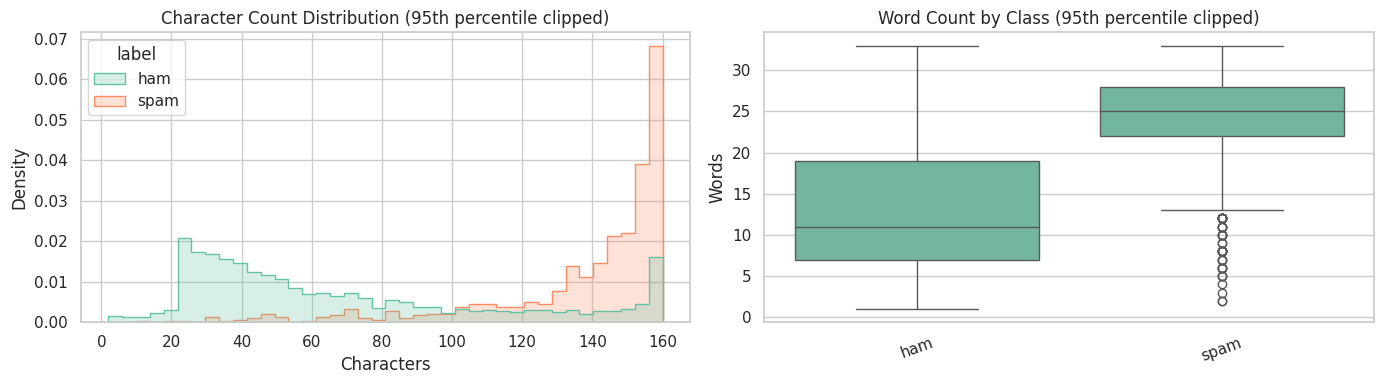

In [7]:
eda_df = basic_text_eda(df)

display(
    eda_df.groupby("label")[["char_count", "word_count", "unique_word_count", "avg_word_length"]]
    .describe()
    .round(2)
)

plot_text_lengths(eda_df)

## 7. Most Frequent Words by Class

In [8]:
for label_value in sorted(df["label"].dropna().unique()):
    print(f"Top words for: {label_value}")
    display(top_words_by_label(df, label_value, n=20))

Top words for: ham


,word,count
0,just,297
1,know,237
2,good,235
3,got,234
4,like,234
5,come,231
6,day,218
7,love,205
8,time,202
9,going,169


Top words for: spam


,word,count
0,free,228
1,txt,170
2,mobile,129
3,stop,128
4,text,126
5,claim,113
6,reply,104
7,www,98
8,prize,93
9,just,79


## 8. Prepare Data for Modeling

Rows after cleaning: 5169


,label,count,percentage
0,ham,4516,87.37
1,spam,653,12.63


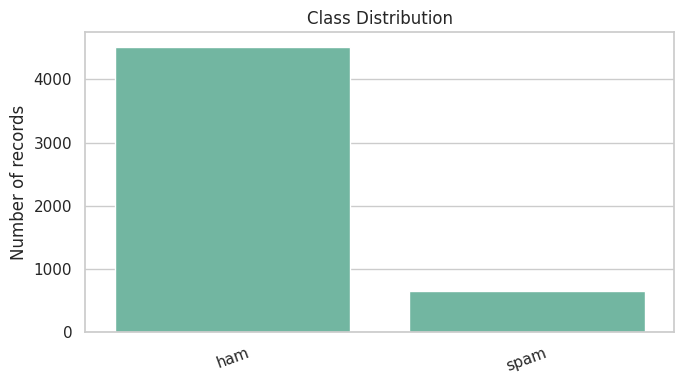

Train size: 4135
Test size: 1034


In [9]:
POSITIVE_LABEL = 'spam'

model_df = df.dropna(subset=["label"]).copy()
model_df["text"] = model_df["text"].fillna("").astype(str)
model_df = model_df[model_df["text"].str.strip().ne("")]
model_df = model_df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("Rows after cleaning:", len(model_df))
show_label_distribution(model_df, label_col="label")

X = model_df["text"]
y = model_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

## 9. Logistic Regression

Logistic Regression classification report

,precision,recall,f1-score,support
ham,0.983444,0.986711,0.985075,903.000000
spam,0.906250,0.885496,0.895753,131.000000
accuracy,0.973888,0.973888,0.973888,0.973888
macro avg,0.944847,0.936104,0.940414,1034.000000
weighted avg,0.973664,0.973888,0.973758,1034.000000


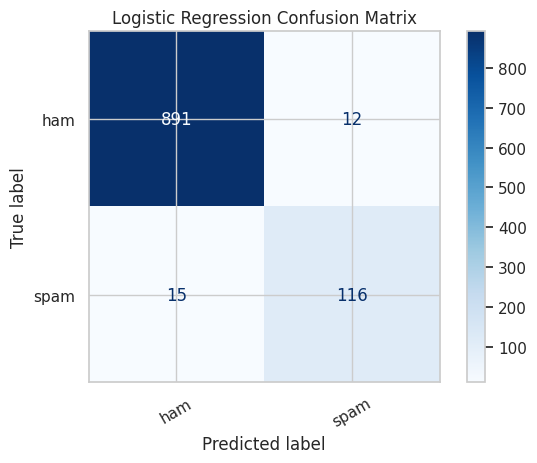

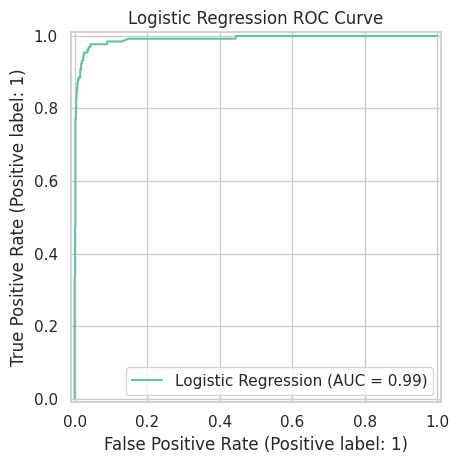

In [10]:
logistic_regression = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_features=12000,
            ),
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

results = []
trained_models = {}

metrics, trained_model = evaluate_model(
    "Logistic Regression",
    logistic_regression,
    X_train,
    X_test,
    y_train,
    y_test,
    positive_label=POSITIVE_LABEL,
)
results.append(metrics)
trained_models["Logistic Regression"] = trained_model

## 10. K-Nearest Neighbors

KNN classification report


,precision,recall,f1-score,support
ham,0.963675,0.998893,0.980968,903.000000
spam,0.989796,0.740458,0.847162,131.000000
accuracy,0.966151,0.966151,0.966151,0.966151
macro avg,0.976736,0.869675,0.914065,1034.000000
weighted avg,0.966985,0.966151,0.964016,1034.000000


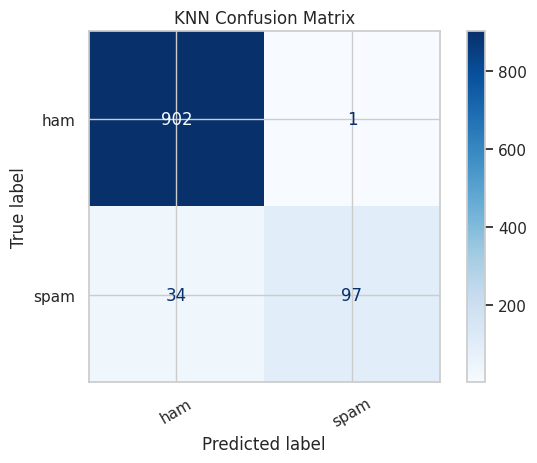

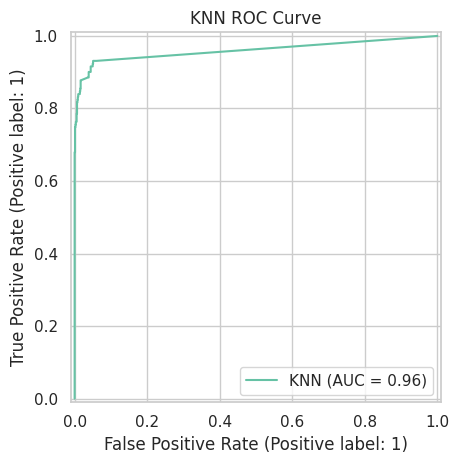

In [11]:
knn = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_features=7000,
            ),
        ),
        (
            "model",
            KNeighborsClassifier(
                n_neighbors=5,
                weights="distance",
                metric="cosine",
                algorithm="brute",
                n_jobs=-1,
            ),
        ),
    ]
)

metrics, trained_model = evaluate_model(
    "KNN",
    knn,
    X_train,
    X_test,
    y_train,
    y_test,
    positive_label=POSITIVE_LABEL,
)
results.append(metrics)
trained_models["KNN"] = trained_model

## 11. Model Comparison

In [12]:
results_df = pd.DataFrame(results).sort_values("weighted_f1", ascending=False).reset_index(drop=True)
display(results_df.round(4))

best_model_name = results_df.loc[0, "model"]
print(f"Best model by weighted F1: {best_model_name}")

,model,accuracy,weighted_precision,weighted_recall,weighted_f1,roc_auc
0,Logistic Regression,0.9739,0.9737,0.9739,0.9738,0.9912
1,KNN,0.9662,0.9670,0.9662,0.9640,0.9601


Best model by weighted F1: Logistic Regression


## 12. Quick Error Check

In [13]:
best_model = trained_models[best_model_name]
y_pred = best_model.predict(X_test)

errors = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": y_pred,
})
errors = errors[errors["actual"] != errors["predicted"]]

print("Number of misclassified examples:", len(errors))
display(errors.head(15))

Number of misclassified examples: 27


,text,actual,predicted
1262,Your daily text from me – a favour this time,ham,spam
5137,Want explicit SEX in 30 secs? Ring 02073162414 now! Costs 20p/min Gsex POBOX 2667 WC1N 3XX,spam,ham
521,You will recieve your tone within the next 24hrs. For Terms and conditions please see Channel U Teletext Pg 750,spam,ham
5139,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE MINS. INDIA CUST SERVs SED YES. L8ER GOT MEGA BILL. 3 DONT GIV A SHIT. BAILIFF DUE IN DAYS. I O £250 3 WANT £800,spam,ham
75,I am waiting machan. Call me once you free.,ham,spam
487,Are you free now?can i call now?,ham,spam
1423,Hi its LUCY Hubby at meetins all day Fri & I will B alone at hotel U fancy cumin over? Pls leave msg 2day 09099726395 Lucy x Calls£1/minMobsmoreLKPOBOX177HP...,spam,ham
3949,Missed call alert. These numbers called but left no message. 07008009200,spam,ham
4806,K k:) sms chat with me.,ham,spam
2303,Babe: U want me dont u baby! Im nasty and have a thing 4 filthyguys. Fancy a rude time with a sexy bitch. How about we go slo n hard! Txt XXX SLO(4msgs),spam,ham


## Conclusion

Use the comparison table above to report which model performed better on this train/test split. In most text-classification problems, Logistic Regression with TF-IDF is a strong baseline because it handles sparse high-dimensional text features well. KNN is included for comparison, but it can be slower and more sensitive to feature dimensionality.